In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/

In [18]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ===============================
#  EXPLAINABILITY LIBRARIES
# ===============================
!pip install lime -q

from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.filters import gaussian

print(" All libraries loaded successfully")

 All libraries loaded successfully


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [20]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [21]:
from torchvision import datasets
from torch.utils.data import ConcatDataset

train_dir = "/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training"
test_dir  = "/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Testing"
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
test_data  = datasets.ImageFolder(test_dir, transform=train_transforms)

# Combine both datasets
full_dataset = ConcatDataset([train_data, test_data])

CLASS_NAMES = train_data.classes

print("Classes:", CLASS_NAMES)
print("Total images:", len(full_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total images: 7200


In [22]:
from torch.utils.data import random_split

dataset_size = len(full_dataset)

train_size = int(0.7 * dataset_size)
test_size  = dataset_size - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size]
)

print("Training Images:", train_size)
print("Testing Images:", test_size)

Training Images: 5040
Testing Images: 2160


In [23]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("DataLoaders Ready")

DataLoaders Ready


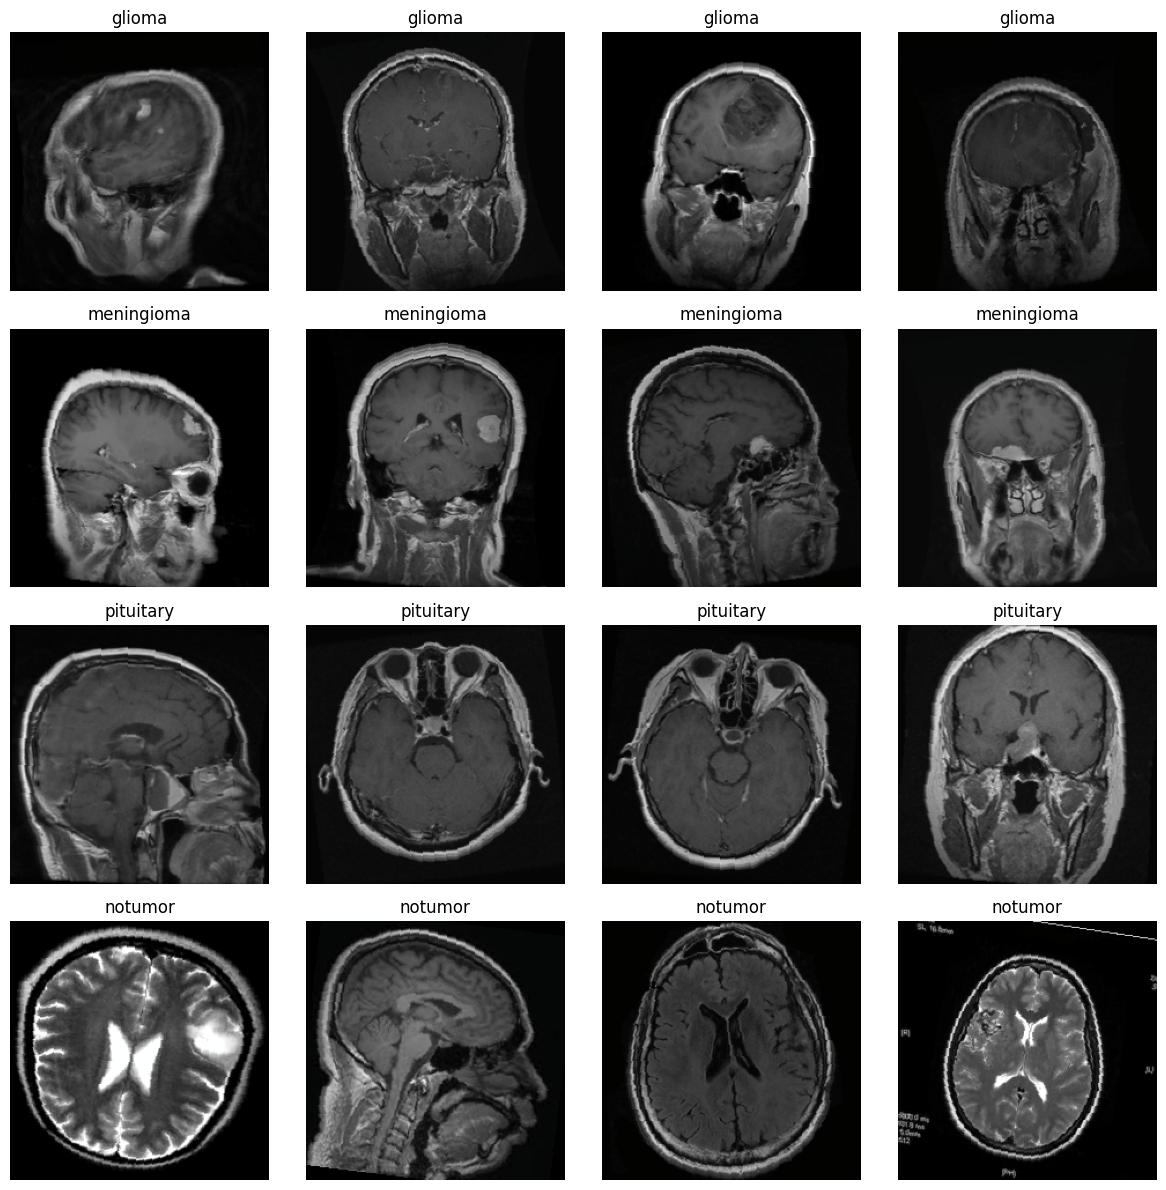

MRI visualization saved!


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Desired class order
display_order = ['glioma', 'meningioma', 'pituitary', 'notumor']

class_images = {cls: [] for cls in display_order}

for images, labels in train_loader:

    for img, label in zip(images, labels):

        class_name = CLASS_NAMES[label]

        if class_name in class_images and len(class_images[class_name]) < 4:
            class_images[class_name].append(img)

    if all(len(v) == 4 for v in class_images.values()):
        break


plt.figure(figsize=(12,12))

index = 1

for cls in display_order:

    for img in class_images[cls]:

        plt.subplot(4,4,index)

        img = img.permute(1,2,0).cpu().numpy()

        # undo normalization
        mean = np.array([0.485,0.456,0.406])
        std  = np.array([0.229,0.224,0.225])

        img = std * img + mean
        img = np.clip(img,0,1)

        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

        index += 1


plt.tight_layout()

plt.savefig("/kaggle/working/mri_samples_per_class.png", dpi=300)

plt.show()

print("MRI visualization saved!")

In [25]:
# Number of classes
NUM_CLASSES = len(CLASS_NAMES)

print("Number of Classes:", NUM_CLASSES)

# Load pretrained Vision Transformer
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Modify classifier head
model.heads.head = nn.Linear(
    model.heads.head.in_features,
    NUM_CLASSES
)

model = model.to(device)

print("ViT Model Loaded")

Number of Classes: 4
ViT Model Loaded


In [26]:
import torch.optim as optim
import torch.nn as nn

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=120
)

print("Optimizer, Loss, Scheduler initialized")





Optimizer, Loss, Scheduler initialized


In [27]:
EPOCHS = 120

history = {
    "train_acc": [],
    "test_acc": [],
    "train_loss": []
}

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)

In [29]:
import os
import torch

checkpoint_path = "/kaggle/working/checkpoint.pth"
best_model_path = "/kaggle/working/best_vit_brain_tumor.pth"

start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    #  Safe scheduler loading
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(" Scheduler loaded")
    else:
        print(" Scheduler not found, using fresh scheduler")

    start_epoch = checkpoint['epoch'] + 1
    print(f" Resuming from epoch {start_epoch}")
else:
    print(" Starting fresh training")
 

 Starting fresh training


In [30]:
import os
print(os.listdir())

['.virtual_documents', 'mri_samples_per_class.png']


In [31]:
import os
import pickle

# HISTORY LOAD / INIT (VERY IMPORTANT)
history_path = "/kaggle/working/history.pkl"

if os.path.exists(history_path):
    with open(history_path, "rb") as f:
        history = pickle.load(f)
    print(" History loaded")
else:
    history = {
        "train_acc": [],
        "test_acc": [],
        "train_loss": []
    }
    print(" New history created")

 New history created


In [32]:
for epoch in range(start_epoch, EPOCHS):

    # -------- TRAINING --------
    model.train()
    correct = 0
    total = 0
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = train_loss / len(train_loader)   # ✅ FIX (average loss)

    # -------- TESTING --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = 100 * correct / total

    # -------- STORE HISTORY (CRITICAL) --------
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    history["train_loss"].append(train_loss)

    # -------- SAVE HISTORY --------
    with open(history_path, "wb") as f:
        pickle.dump(history, f)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

    # -------- SAVE BEST MODEL --------
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), best_model_path)
        print(" Best model saved!")

    # -------- SAVE CHECKPOINT --------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
    }, checkpoint_path)

Epoch [1/120] Train Acc: 43.31% | Test Acc: 51.20%
 Best model saved!
Epoch [2/120] Train Acc: 61.39% | Test Acc: 67.55%
 Best model saved!
Epoch [3/120] Train Acc: 70.32% | Test Acc: 74.72%
 Best model saved!
Epoch [4/120] Train Acc: 78.21% | Test Acc: 78.43%
 Best model saved!
Epoch [5/120] Train Acc: 82.18% | Test Acc: 77.31%
Epoch [6/120] Train Acc: 83.59% | Test Acc: 88.15%
 Best model saved!
Epoch [7/120] Train Acc: 86.41% | Test Acc: 86.39%
Epoch [8/120] Train Acc: 88.33% | Test Acc: 89.26%
 Best model saved!
Epoch [9/120] Train Acc: 88.47% | Test Acc: 89.63%
 Best model saved!
Epoch [10/120] Train Acc: 90.10% | Test Acc: 91.34%
 Best model saved!
Epoch [11/120] Train Acc: 90.69% | Test Acc: 91.11%
Epoch [12/120] Train Acc: 91.61% | Test Acc: 92.73%
 Best model saved!
Epoch [13/120] Train Acc: 91.88% | Test Acc: 92.04%
Epoch [14/120] Train Acc: 92.46% | Test Acc: 91.02%
Epoch [15/120] Train Acc: 93.27% | Test Acc: 89.81%
Epoch [16/120] Train Acc: 93.73% | Test Acc: 90.79%
Epoch 

In [33]:
print(len(history["train_acc"]))
print(len(history["test_acc"]))

120
120


In [34]:
print(len(history["train_acc"]))

120


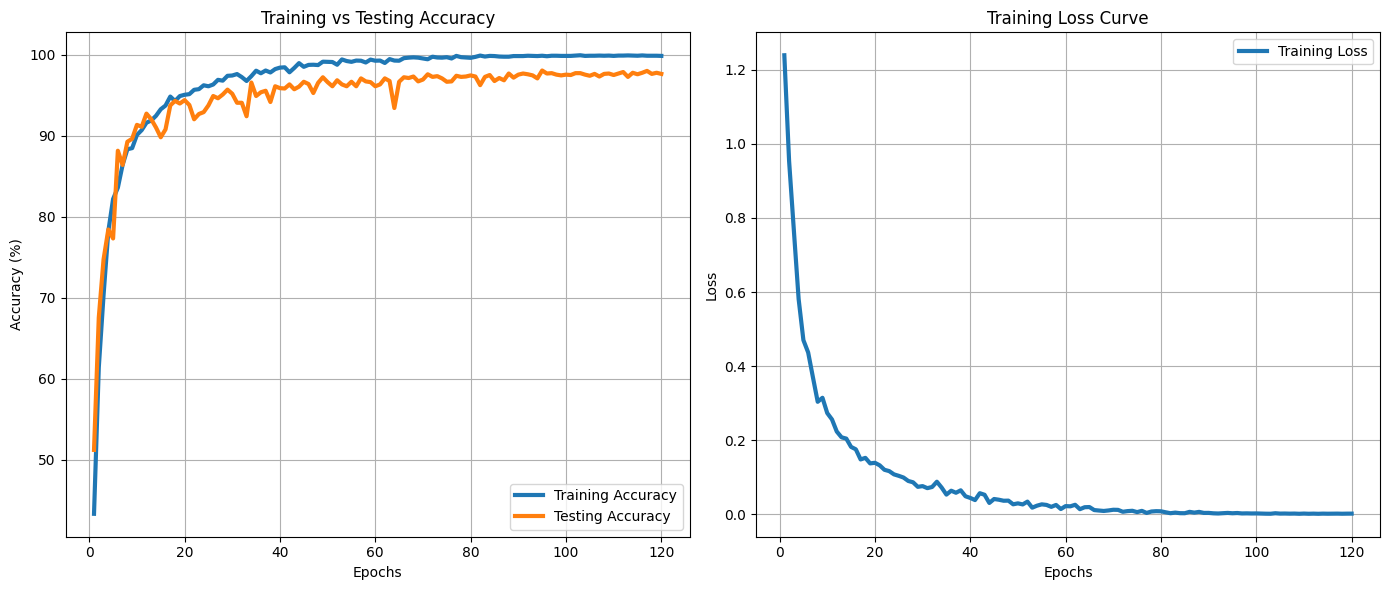

Accuracy graph saved!


In [35]:
epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.plot(epochs_range, history["train_acc"], label="Training Accuracy", linewidth=3)
plt.plot(epochs_range, history["test_acc"], label="Testing Accuracy", linewidth=3)

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Testing Accuracy")

plt.legend()
plt.grid()

plt.subplot(1,2,2)

plt.plot(epochs_range, history["train_loss"], label="Training Loss", linewidth=3)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig("/kaggle/working/accuracy_graph.png", dpi=300)

plt.show()
print("Accuracy graph saved!")

In [36]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

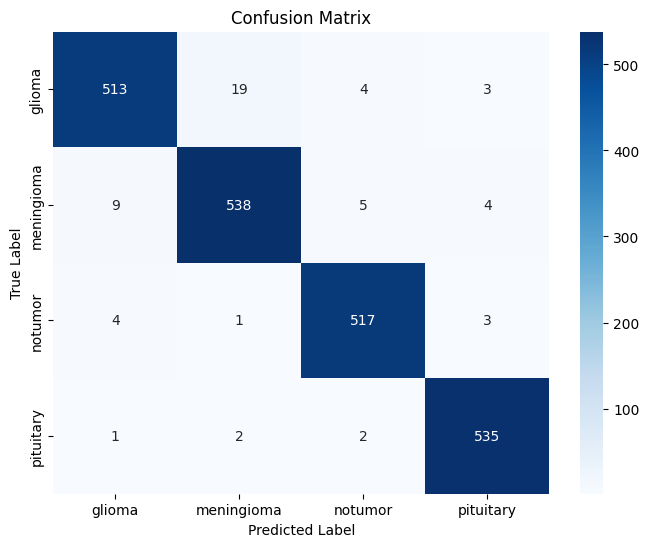

Confusion matrix saved!


In [37]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300)

plt.show()

print("Confusion matrix saved!")

In [38]:
import numpy as np

sensitivity = []
specificity = []

for i in range(len(cm)):
    
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sens = TP / (TP + FN)
    spec = TN / (TN + FP)

    sensitivity.append(sens)
    specificity.append(spec)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

print("Average Sensitivity:", np.mean(sensitivity))
print("Average Specificity:", np.mean(specificity))

Sensitivity: [np.float64(0.9517625231910947), np.float64(0.9676258992805755), np.float64(0.9847619047619047), np.float64(0.9907407407407407)]
Specificity: [np.float64(0.9913633559531153), np.float64(0.986284289276808), np.float64(0.9932721712538226), np.float64(0.9938271604938271)]
Average Sensitivity: 0.9737227669935788
Average Specificity: 0.9911867442443932


In [39]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(all_labels, all_preds) * 100

print("Accuracy:", accuracy)

print(classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES
))

Accuracy: 97.36111111111111
              precision    recall  f1-score   support

      glioma       0.97      0.95      0.96       539
  meningioma       0.96      0.97      0.96       556
     notumor       0.98      0.98      0.98       525
   pituitary       0.98      0.99      0.99       540

    accuracy                           0.97      2160
   macro avg       0.97      0.97      0.97      2160
weighted avg       0.97      0.97      0.97      2160



In [40]:
torch.save(model.state_dict(), "/kaggle/working/best_vit_brain_tumor.pth")
print(" Model saved successfully!")

 Model saved successfully!


In [41]:
import os
print(os.listdir("/kaggle/working"))

['.virtual_documents', 'accuracy_graph.png', 'history.pkl', 'mri_samples_per_class.png', 'checkpoint.pth', 'best_vit_brain_tumor.pth', 'confusion_matrix.png']


In [42]:
torch.save(model.state_dict(), "/kaggle/working/best_vit_brain_tumor.pth")
print("Model saved successfully!")

Model saved successfully!


In [43]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [44]:
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [ ]:
model.load_state_dict(torch.load("/kaggle/working/best_vit_brain_tumor.pth", map_location=device))
model.eval()
model.to(device)

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :]
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.permute(0, 3, 1, 2)
    return result

target_layers = [model.encoder.layers[-1].ln_1]

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = STD * img + MEAN
    img = np.clip(img, 0, 1)
    return img

print("Ready!")

Ready!


In [ ]:
sample_images = {cls: [] for cls in CLASS_NAMES}

for images, labels in test_loader:
    for img, lbl in zip(images, labels):
        cls = CLASS_NAMES[lbl.item()]
        if len(sample_images[cls]) < 2:
            sample_images[cls].append(img)
    if all(len(v) == 2 for v in sample_images.values()):
        break

print("2 images per class collected!")

2 images per class collected!


In [ ]:
def predict_fn(images_np):
    model.eval()
    imgs   = torch.tensor(images_np, dtype=torch.float32).permute(0, 3, 1, 2)
    mean_t = torch.tensor(MEAN, dtype=torch.float32).view(1, 3, 1, 1)
    std_t  = torch.tensor(STD,  dtype=torch.float32).view(1, 3, 1, 1)
    imgs   = (imgs - mean_t) / std_t
    imgs   = torch.nn.functional.interpolate(imgs, size=(224, 224), mode='bilinear', align_corners=False)
    imgs   = imgs.to(device)
    with torch.no_grad():
        outputs = model(imgs)
        probs   = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

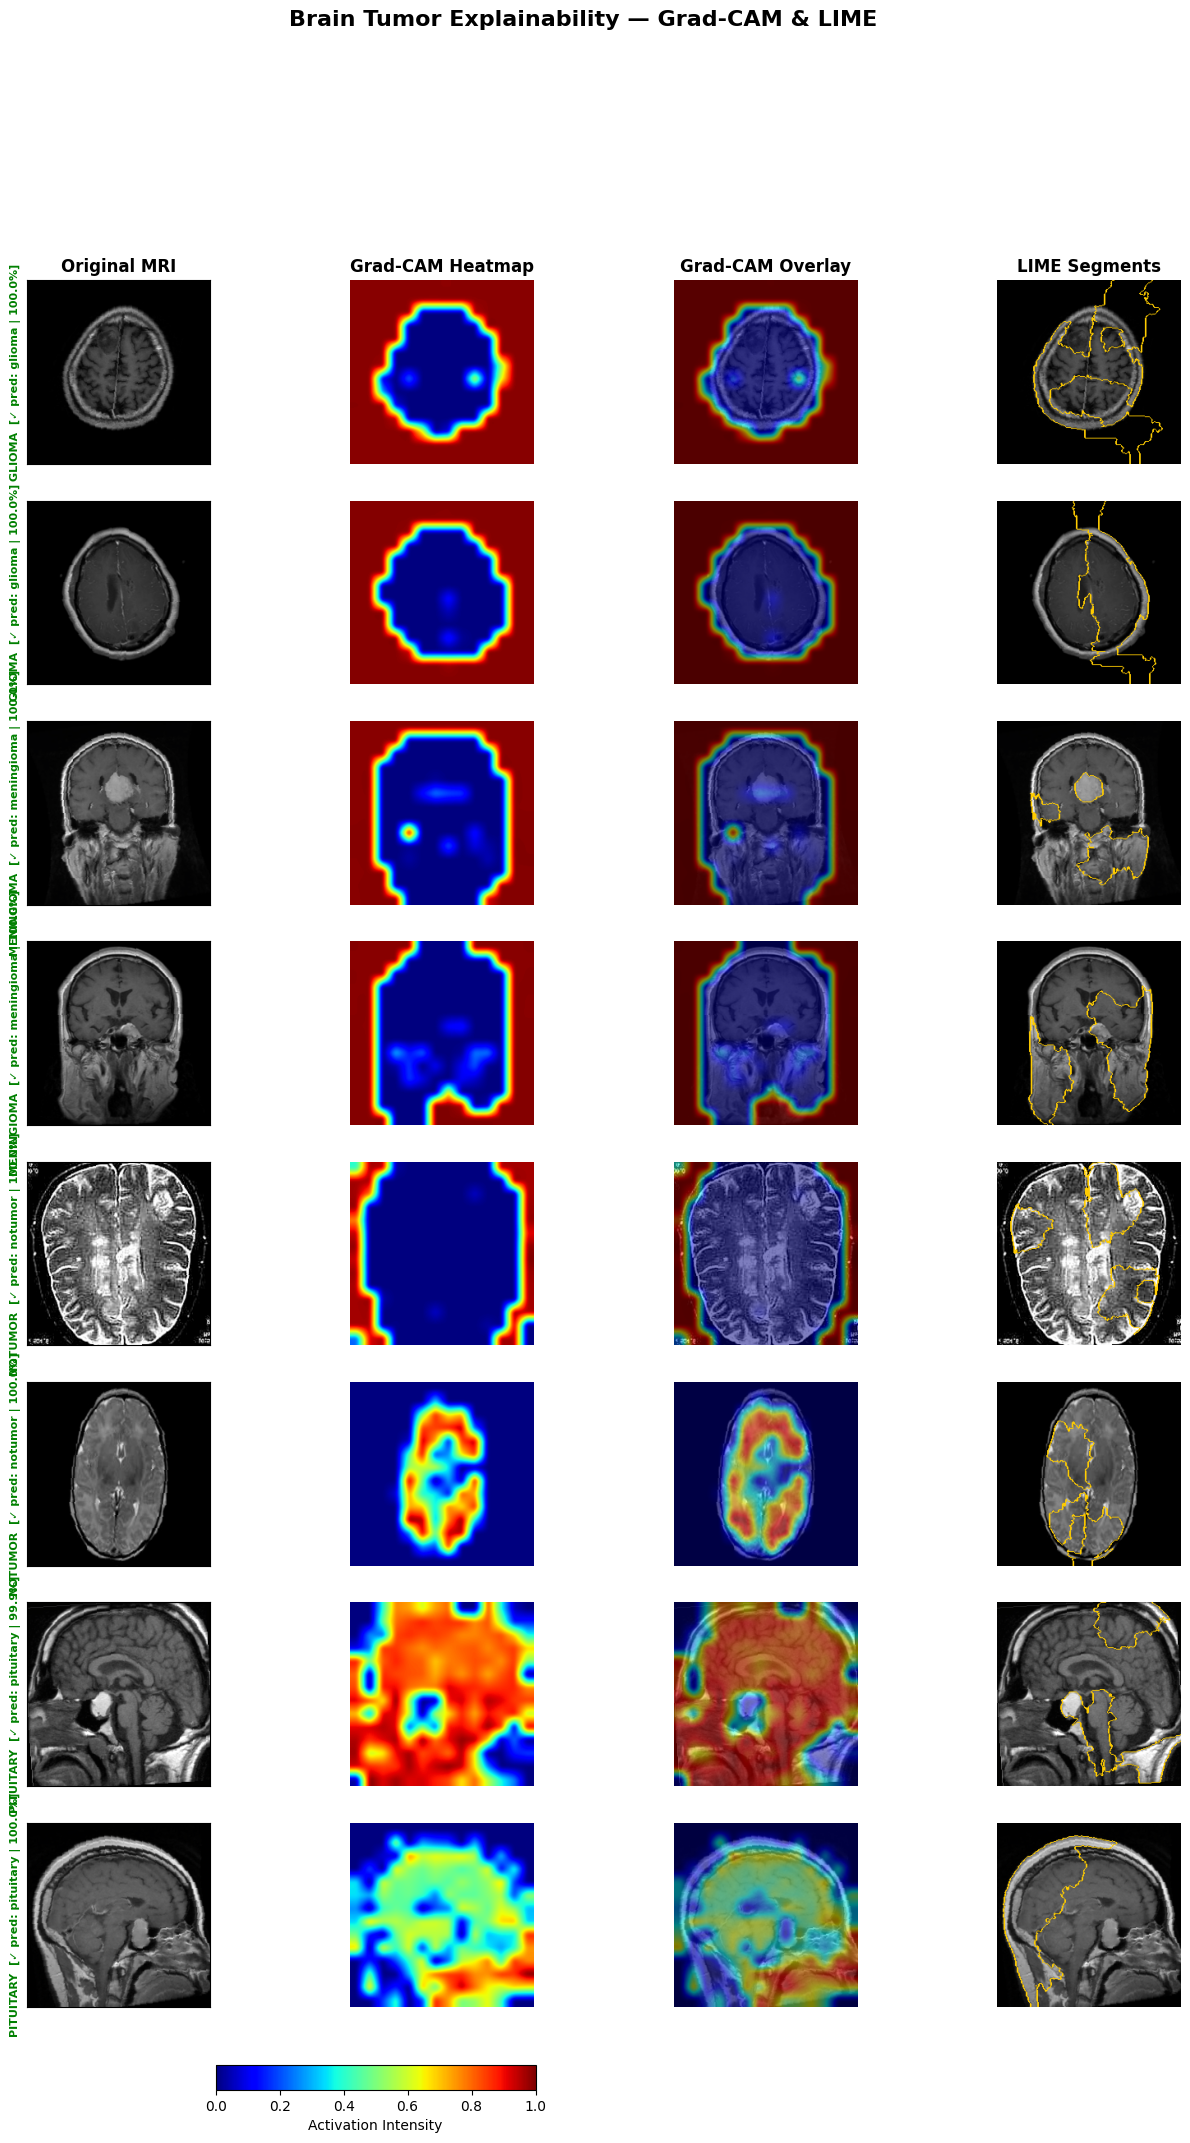

Saved: explainability_gradcam_lime.png


In [52]:
from scipy.ndimage import gaussian_filter

N_ROWS     = len(CLASS_NAMES) * 2
COL_TITLES = ["Original MRI", "Grad-CAM Heatmap", "Grad-CAM Overlay", "LIME Segments"]

fig, axes = plt.subplots(N_ROWS, 4, figsize=(16, N_ROWS * 2.6))
fig.suptitle("Brain Tumor Explainability — Grad-CAM & LIME",
             fontsize=16, fontweight='bold', y=1.01)

for col, title in enumerate(COL_TITLES):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=6)

explainer = lime_image.LimeImageExplainer(random_state=42)
row = 0

with GradCAM(model=model,
             target_layers=target_layers,
             reshape_transform=reshape_transform) as cam:

    for cls in CLASS_NAMES:
        for img_tensor in sample_images[cls]:

            img_np    = denormalize(img_tensor)
            img_input = img_tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(img_input)
                pred   = output.argmax(1).item()
                conf   = torch.softmax(output, dim=1)[0, pred].item() * 100

            pred_label = CLASS_NAMES[pred]

            # ── Grad-CAM with smoothing ──────────────────────────────
            grayscale_cam = cam(input_tensor=img_input,
                                targets=[ClassifierOutputTarget(pred)])[0]
            grayscale_cam = gaussian_filter(grayscale_cam, sigma=2)
            overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

            # ── LIME ─────────────────────────────────────────────────
            explanation = explainer.explain_instance(
                img_np.astype(np.float64), predict_fn,
                top_labels=1, hide_color=0,
                num_samples=1000, random_seed=42
            )
            _, mask = explanation.get_image_and_mask(
                label=pred,
                positive_only=True,
                num_features=4,
                hide_rest=False
            )
            # Draw boundaries on ORIGINAL image (not lime_img)
            lime_vis = mark_boundaries(img_np, mask, color=(1, 0.8, 0), mode='outer')

            # ── Plot ─────────────────────────────────────────────────
            match     = "✓" if cls == pred_label else "✗"
            row_title = f"{cls.upper()}  [{match} pred: {pred_label} | {conf:.1f}%]"

            axes[row, 0].imshow(img_np)
            axes[row, 0].set_ylabel(row_title, fontsize=8, fontweight='bold',
                                    color='green' if cls == pred_label else 'red')
            axes[row, 0].tick_params(left=False, bottom=False,
                                     labelleft=False, labelbottom=False)

            axes[row, 1].imshow(grayscale_cam, cmap='jet', vmin=0, vmax=1)
            axes[row, 1].axis('off')

            axes[row, 2].imshow(overlay)
            axes[row, 2].axis('off')

            axes[row, 3].imshow(lime_vis)
            axes[row, 3].axis('off')

            row += 1

# Fixed colorbar — no tight_layout conflict
plt.subplots_adjust(bottom=0.05)
cbar_ax = fig.add_axes([0.27, 0.01, 0.2, 0.012])
sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=1))
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='Activation Intensity')

plt.savefig("/kaggle/working/explainability_gradcam_lime.png", dpi=250, bbox_inches='tight')
plt.show()
print("Saved: explainability_gradcam_lime.png")

In [ ]:
from sklearn.model_selection import KFold

K_FOLDS       = 5
EPOCHS_KFOLD  = 10
kf            = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
kfold_results = []

print("\n\nStarting K-Fold Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset)):
    print(f"\n========== Fold {fold+1}/{K_FOLDS} ==========")

    train_subset   = Subset(full_dataset, train_idx)
    val_subset     = Subset(full_dataset, val_idx)
    train_loader_k = DataLoader(train_subset, batch_size=64, shuffle=True,  num_workers=2)
    val_loader_k   = DataLoader(val_subset,   batch_size=64, shuffle=False, num_workers=2)

    weights  = ViT_B_16_Weights.DEFAULT
    model_k  = vit_b_16(weights=weights)
    model_k.heads.head = nn.Linear(model_k.heads.head.in_features, NUM_CLASSES)
    model_k  = model_k.to(device)

    criterion_k = nn.CrossEntropyLoss()
    optimizer_k = optim.AdamW(model_k.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler_k = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_k, T_max=EPOCHS_KFOLD)

    for epoch in range(EPOCHS_KFOLD):
        model_k.train()
        correct, total = 0, 0
        for images, labels in train_loader_k:
            images, labels = images.to(device), labels.to(device)
            optimizer_k.zero_grad()
            outputs = model_k(images)
            loss    = criterion_k(outputs, labels)
            loss.backward()
            optimizer_k.step()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
        train_acc = 100 * correct / total

        model_k.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader_k:
                images, labels = images.to(device), labels.to(device)
                outputs = model_k(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_acc = 100 * correct / total
        scheduler_k.step()

        print(f"Epoch {epoch+1}/{EPOCHS_KFOLD} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    kfold_results.append(val_acc)
    del model_k
    torch.cuda.empty_cache()



Starting K-Fold Cross Validation...


========== Fold 1/5 ==========
Epoch 1/10 | Train Acc: 50.42% | Val Acc: 57.64%
Epoch 2/10 | Train Acc: 68.68% | Val Acc: 78.75%
Epoch 3/10 | Train Acc: 80.36% | Val Acc: 85.62%
Epoch 4/10 | Train Acc: 85.73% | Val Acc: 89.17%
Epoch 5/10 | Train Acc: 89.24% | Val Acc: 90.07%
Epoch 6/10 | Train Acc: 91.28% | Val Acc: 90.90%
Epoch 7/10 | Train Acc: 92.95% | Val Acc: 91.46%
Epoch 8/10 | Train Acc: 95.49% | Val Acc: 92.64%
Epoch 9/10 | Train Acc: 96.72% | Val Acc: 95.00%
Epoch 10/10 | Train Acc: 97.48% | Val Acc: 95.69%

========== Fold 2/5 ==========
Epoch 1/10 | Train Acc: 46.94% | Val Acc: 60.14%
Epoch 2/10 | Train Acc: 61.61% | Val Acc: 69.51%
Epoch 3/10 | Train Acc: 70.52% | Val Acc: 74.24%
Epoch 4/10 | Train Acc: 77.03% | Val Acc: 78.33%
Epoch 5/10 | Train Acc: 80.92% | Val Acc: 84.24%
Epoch 6/10 | Train Acc: 86.44% | Val Acc: 86.11%
Epoch 7/10 | Train Acc: 88.52% | Val Acc: 87.64%
Epoch 8/10 | Train Acc: 90.80% | Val Acc: 90.56%
Epoch 9/10 | T

In [ ]:
print("\n========== K-FOLD RESULTS ==========")
for i, acc in enumerate(kfold_results):
    print(f"Fold {i+1}: {acc:.2f}%")
print(f"\nAverage Accuracy: {np.mean(kfold_results):.2f}%")


========== K-FOLD RESULTS ==========
Fold 1: 95.69%
Fold 2: 92.57%
Fold 3: 94.38%
Fold 4: 92.36%
Fold 5: 96.32%

Average Accuracy: 94.26%
